In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import auc

In [9]:
"""
Load data.
"""
knn_gap = pd.read_csv("../../data/knn_overfit_gap.csv")
rf_gap  = pd.read_csv("../../data/rf_overfit_gap.csv")
lr_gap  = pd.read_csv("../../data/lr_overfit_gap.csv")

knn_cm = pd.read_csv("../../data/knn_confusion_matrix.csv", index_col=0).values
rf_cm  = pd.read_csv("../../data/rf_confusion_matrix.csv",  index_col=0).values
lr_cm  = pd.read_csv("../../data/lr_confusion_matrix.csv",  index_col=0).values

knn_roc = pd.read_csv("../../data/knn_roc_curve.csv")
rf_roc  = pd.read_csv("../../data/rf_roc_curve.csv")
lr_roc  = pd.read_csv("../../data/lr_roc_curve.csv")

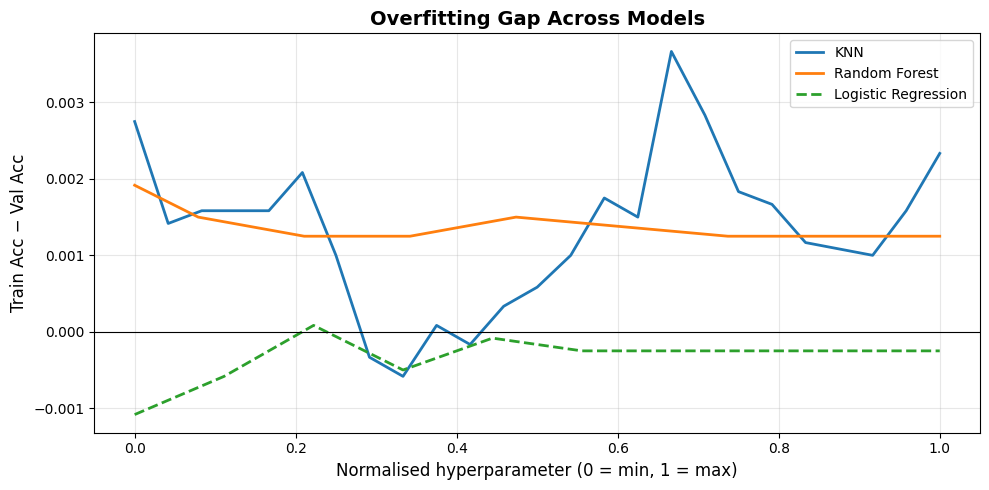

In [10]:
"""
Overfitting.
    Each model has a different hyperparameter axis (k, n_estimators, C) so we
    normalise each to put them on the same plot.
    LR has multiple class-weight settings — we plot each as a separate line.
"""

fig, ax = plt.subplots(figsize=(10, 5))

x = (knn_gap["k"] - knn_gap["k"].min()) / (knn_gap["k"].max() - knn_gap["k"].min())
ax.plot(x, knn_gap["overfit_gap"], linewidth=2, label="KNN")

x = (rf_gap["n_estimators"] - rf_gap["n_estimators"].min()) / (rf_gap["n_estimators"].max() - rf_gap["n_estimators"].min())
ax.plot(x, rf_gap["overfit_gap"], linewidth=2, label="Random Forest")

# for lr there are two class weights but they seem identical? 
lr_subset = lr_gap[lr_gap["class_weight"] == lr_gap["class_weight"].iloc[0]].sort_values("C")
x = (np.log10(lr_subset["C"]) - np.log10(lr_subset["C"].min())) / \
    (np.log10(lr_subset["C"].max()) - np.log10(lr_subset["C"].min()))
ax.plot(x, lr_subset["overfit_gap"], linewidth=2, linestyle="--", label="Logistic Regression")

ax.axhline(y=0, color="black", linewidth=0.8)
ax.set_xlabel("Normalised hyperparameter (0 = min, 1 = max)", fontsize=12)
ax.set_ylabel("Train Acc − Val Acc", fontsize=12)
ax.set_title("Overfitting Gap Across Models", fontsize=14, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../../plots/comparison_overfit_gap.png", dpi=300, bbox_inches="tight")
plt.show()

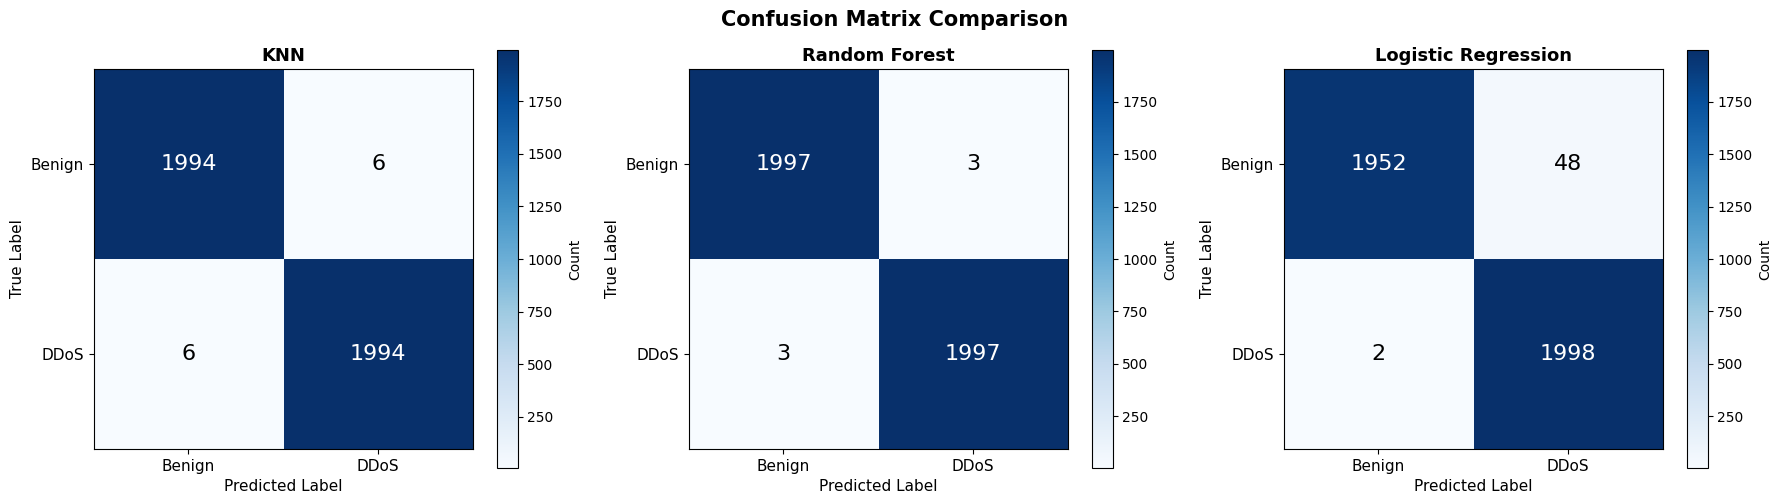

In [11]:
"""
Confusion matrices.
    Just plotted side by side.
"""
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ["Benign", "DDoS"]
titles = ["KNN", "Random Forest", "Logistic Regression"]

for ax, cm, title in zip(axes, [knn_cm, rf_cm, lr_cm], titles):
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.colorbar(im, ax=ax, label="Count")
    thresh = cm.max() / 2.0
    for i in range(2):
        for j in range(2):
            ax.text(j, i, format(cm[i, j], "d"),
                    ha="center", va="center", fontsize=16,
                    color="white" if cm[i, j] > thresh else "black")
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels, fontsize=11)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels, fontsize=11)
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")

fig.suptitle("Confusion Matrix Comparison", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("../../plots/comparison_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

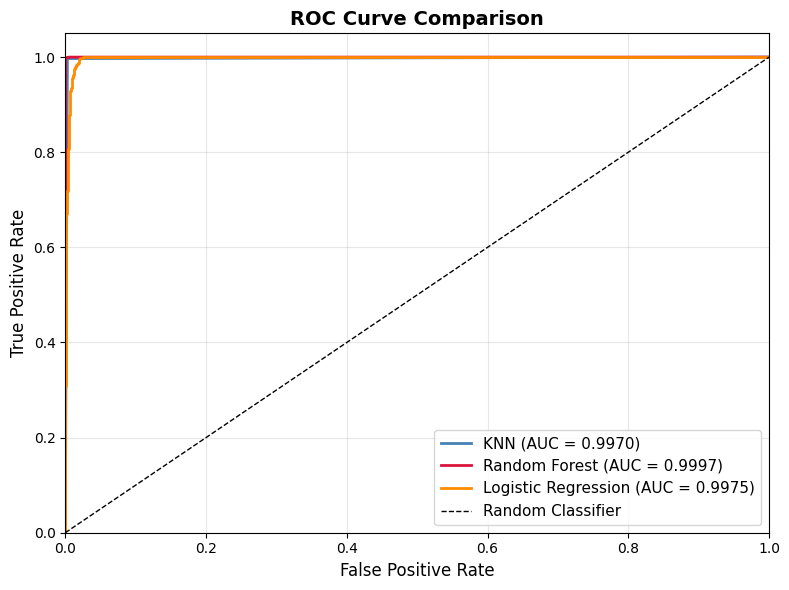

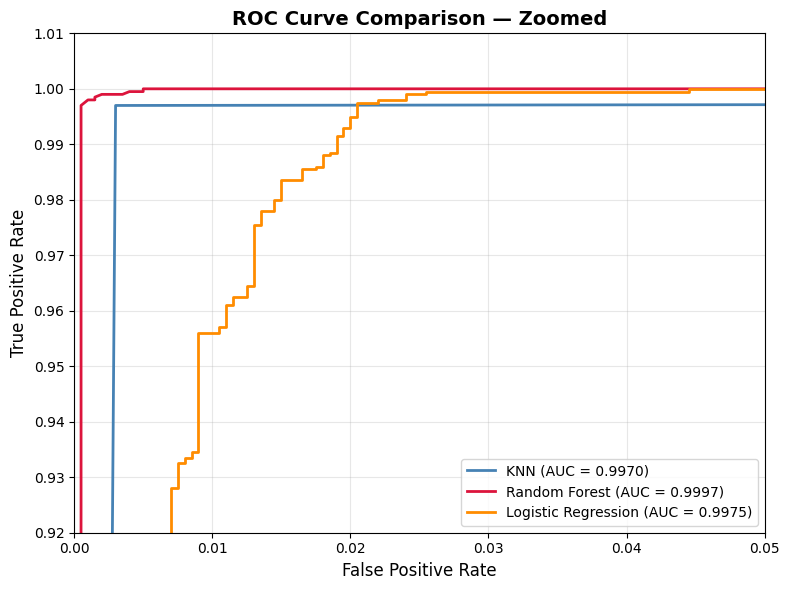

In [12]:
"""
ROC Curve.
    This is hard to see, so we then zoom in on the top left.
"""
fig, ax = plt.subplots(figsize=(8, 6))

for roc, label, color in [
    (knn_roc, "KNN",                "steelblue"),
    (rf_roc,  "Random Forest",      "crimson"),
    (lr_roc,  "Logistic Regression","darkorange"),
]:
    roc_auc = auc(roc["fpr"], roc["tpr"])
    ax.plot(roc["fpr"], roc["tpr"], linewidth=2, color=color,
            label=f"{label} (AUC = {roc_auc:.4f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve Comparison", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../../plots/comparison_roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()

# zooming in
fig, ax = plt.subplots(figsize=(8, 6))

for roc, label, color in [
    (knn_roc, "KNN",                 "steelblue"),
    (rf_roc,  "Random Forest",       "crimson"),
    (lr_roc,  "Logistic Regression", "darkorange"),
]:
    roc_auc = auc(roc["fpr"], roc["tpr"])
    ax.plot(roc["fpr"], roc["tpr"], linewidth=2, color=color,
            label=f"{label} (AUC = {roc_auc:.4f})")

ax.set_xlim([0.0, 0.05])
ax.set_ylim([0.92, 1.01])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve Comparison — Zoomed", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../../plots/comparison_roc_curves_zoomed.png", dpi=300, bbox_inches="tight")
plt.show()